In [1]:
from functools import partial

# If you are on Colab, uncomment the relevant curl line below.
# !curl -o bellmax.py https://raw.githubusercontent.com/MaxMSun/mcts-tutorial/refs/heads/main/bellmax.py

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize
from IPython.display import HTML
from tqdm.auto import tqdm

# !curl -o bellmax.py https://raw.githubusercontent.com/MaxMSun/mcts-tutorial/refs/heads/main/bellmax.py
import bellmax as bmx

In [2]:
# Core: environment and MCTS selection.
class GridWorld(bmx.MCTS):
    def __init__(self, num_sim=1000, exploration=1.0, max_depth=16):
        super().__init__(max_depth=max_depth, num_sim=num_sim)
        self.exploration = exploration
        self.size = 10
        self.directions = jnp.array([[-1, 0], [0, 1], [1, 0], [0, -1]])
        self.walls = jnp.zeros((self.size, self.size), dtype=bool)
        self.walls = self.walls.at[3:7, 3].set(True)
        self.walls = self.walls.at[3:7, 6].set(True)

    def actions(self, state):
        return self.directions

    def transition(self, state, action):
        candidate = state + action
        inside = jnp.all((candidate >= 0) & (candidate < self.size))
        row, column = jnp.clip(candidate, 0, self.size - 1)
        blocked = ~inside | self.walls[row, column]
        return jnp.where(blocked, state, candidate)

    def reward(self, state, action, next_state, goal):
        return -jnp.sum(jnp.abs(next_state - goal)).astype(jnp.float32)

    def terminal(self, state, goal):
        return jnp.all(state == goal)

    def select(self, key, state, actions, visits, values):
        bonus = self.exploration * jnp.sqrt(jnp.log(visits.sum() + 1) / visits)
        return jnp.argmax(values + bonus)


start = jnp.array([8, 1])
goal = jnp.array([1, 8])
key = jax.random.key(7)
search = GridWorld(num_sim=1000, exploration=5.0, max_depth=16)

In [3]:
# Visualization helpers.
def draw_grid(ax, world, start, goal):
    ax.imshow(np.where(world.walls, 1.0, np.nan), cmap="Greys", vmin=0, vmax=1)
    ax.scatter(start[1], start[0], s=150, color="black", label="current state", zorder=5)
    ax.scatter(goal[1], goal[0], s=320, color="gold", marker="*",
               edgecolor="black", label="goal", zorder=5)
    ax.set_xticks(np.arange(-0.5, world.size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, world.size, 1), minor=True)
    ax.grid(which="minor", color="#dddddd", linewidth=0.6)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.set_xlim(-0.5, world.size - 0.5)
    ax.set_ylim(world.size - 0.5, -0.5)
    ax.set_aspect("equal")


def spatial_action_values(tree, world):
    count = int(tree.size)
    states = np.asarray(tree.state[:count])
    children = np.asarray(tree.children[:count])
    nodes, actions = np.nonzero(children >= 0)
    edges = children[nodes, actions]
    rows, columns = states[nodes].T
    shape = (world.size, world.size, len(world.directions))
    total = np.zeros(shape)
    visits = np.zeros(shape, dtype=int)
    edge_visits = np.asarray(tree.visits)[edges]
    edge_values = np.asarray(tree.value_sum)[edges] / edge_visits
    # Pool repeated (state, action) pairs across tree depths by visit count.
    np.add.at(total, (rows, columns, actions), edge_values * edge_visits)
    np.add.at(visits, (rows, columns, actions), edge_visits)
    q = np.divide(total, visits, out=np.full(shape, np.nan), where=visits > 0)
    return q, visits


def state_values(q):
    known = np.any(np.isfinite(q), axis=-1)
    v = np.max(np.where(np.isfinite(q), q, -np.inf), axis=-1)
    v[~known] = np.nan
    v[tuple(np.asarray(goal))] = 0.0
    return v


def draw_action_values(ax, world, q, visits, norm, current_state):
    draw_grid(ax, world, current_state, goal)
    destinations = []
    walls = np.asarray(world.walls)
    for row, column, action in zip(*np.nonzero(visits)):
        dr, dc = np.asarray(world.directions[action])
        next_row, next_column = row + dr, column + dc
        inside = 0 <= next_row < world.size and 0 <= next_column < world.size
        if not inside or walls[next_row, next_column]:
            continue
        destinations.append((next_row, next_column))
        x, y = column - 0.07 * dr, row + 0.07 * dc
        width = 0.5 + 4 * float(norm(q[row, column, action]))
        ax.annotate("", xy=(x + dc, y + dr), xytext=(x, y),
                    arrowprops=dict(arrowstyle="-|>", color="C1",
                                    lw=width, alpha=0.75, shrinkA=8, shrinkB=8))
    if destinations:
        states = np.unique(destinations, axis=0)
        ax.scatter(states[:, 1], states[:, 0], s=180, facecolors="none",
                   edgecolors="black", linewidths=1.5, zorder=4)


def draw_state_values(ax, world, v, norm, current_state):
    ax.imshow(v, cmap="Blues", norm=norm)
    draw_grid(ax, world, current_state, goal)


def comparison_axes():
    fig, axes = plt.subplots(4, 4, figsize=(12, 12), dpi=90, constrained_layout=True)
    for row, exploration in enumerate(exploration_coefficients):
        for column, num_sim in enumerate(simulation_counts):
            if row == 0:
                axes[row, column].set_title(f"{num_sim:,} simulations")
            if column == 0:
                axes[row, column].set_ylabel(f"exploration = {exploration:g}")
    return fig, axes

In [4]:
# Animation helpers.
@partial(jax.jit, static_argnums=(0, 4))
def search_snapshots(search, key, state, goal, every):
    tree = search._init_tree(state, search.actions(state))

    def record(tree, first):
        def simulate(index, tree):
            return search._simulate(jax.random.fold_in(key, index), tree, (goal,))

        last = jnp.minimum(first + every, search.num_sim)
        tree = jax.lax.fori_loop(first, last, simulate, tree)
        return tree, tree

    _, snapshots = jax.lax.scan(record, tree, jnp.arange(0, search.num_sim, every))
    return snapshots


def animate_search(world, frames, labels, interval):
    values = np.concatenate([q[np.isfinite(q)] for _, q, _, _ in frames])
    norm = Normalize(vmin=values.min(), vmax=0)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=90, constrained_layout=True)

    def update(index):
        current_state, q, visits, path = frames[index]
        for ax in axes:
            ax.clear()
        draw_action_values(axes[0], world, q, visits, norm, current_state)
        draw_state_values(axes[1], world, state_values(q), norm, current_state)
        for ax, title in zip(axes, ["Q-values", "State values"]):
            ax.set_title(title, fontsize=14)
            if len(path) > 1:
                ax.plot(path[:, 1], path[:, 0], color="black", lw=2, zorder=3)
        fig.suptitle(labels[index], fontsize=15)
        progress.update(max(0, index + 1 - progress.n))

    with tqdm(total=len(frames), desc="Rendering animation", unit="frame", leave=False) as progress:
        animation = FuncAnimation(fig, update, frames=len(frames), interval=interval)
        html = HTML(animation.to_jshtml(default_mode="once"))
    plt.close(fig)
    return html

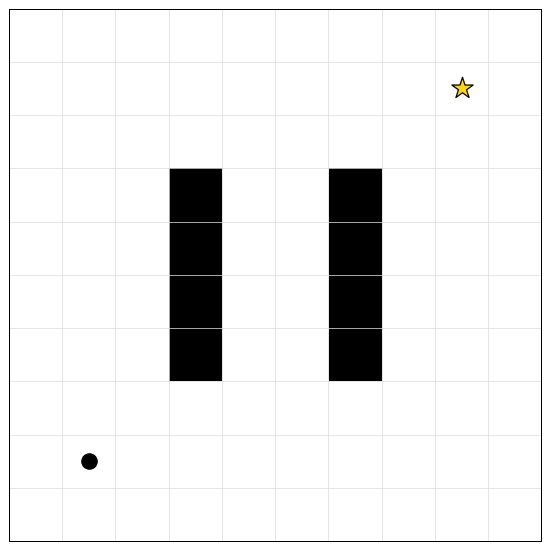

In [5]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=90, constrained_layout=True)
draw_grid(ax, search, start, goal)
plt.show()

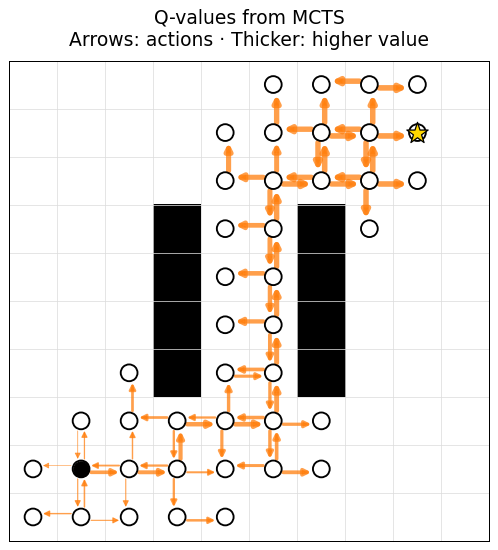

In [6]:
result = search.search(key, start, goal)
q, visits = spatial_action_values(result.tree, search)
v = state_values(q)
value_scale = Normalize(vmin=np.nanmin(q), vmax=0)

fig, ax = plt.subplots(figsize=(6, 6), dpi=90, constrained_layout=True)
draw_action_values(ax, search, q, visits, value_scale, start)
ax.set_title("Q-values from MCTS\nArrows: actions · Thicker: higher value", fontsize=15, pad=12)
plt.show()

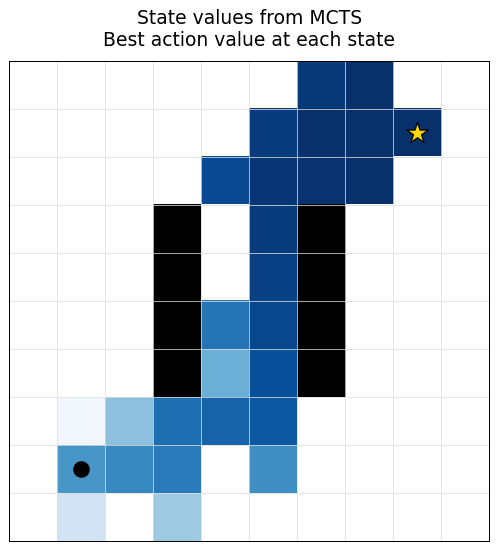

In [7]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=90, constrained_layout=True)
draw_state_values(ax, search, v, value_scale, start)
ax.set_title("State values from MCTS\nBest action value at each state", fontsize=15, pad=12)
plt.show()

In [8]:
simulations_per_frame = 20
snapshots = jax.device_get(search_snapshots(search, key, start, goal, simulations_per_frame))
search_frames = []

for index in range(len(snapshots.size)):
    tree = jax.tree.map(lambda values: values[index], snapshots)
    frame_q, frame_visits = spatial_action_values(tree, search)
    search_frames.append((start, frame_q, frame_visits, np.asarray([start])))

simulation_labels = [f"Simulation {min((i + 1) * simulations_per_frame, search.num_sim)}"
                     for i in range(len(search_frames))]
animate_search(search, search_frames, simulation_labels, interval=150)

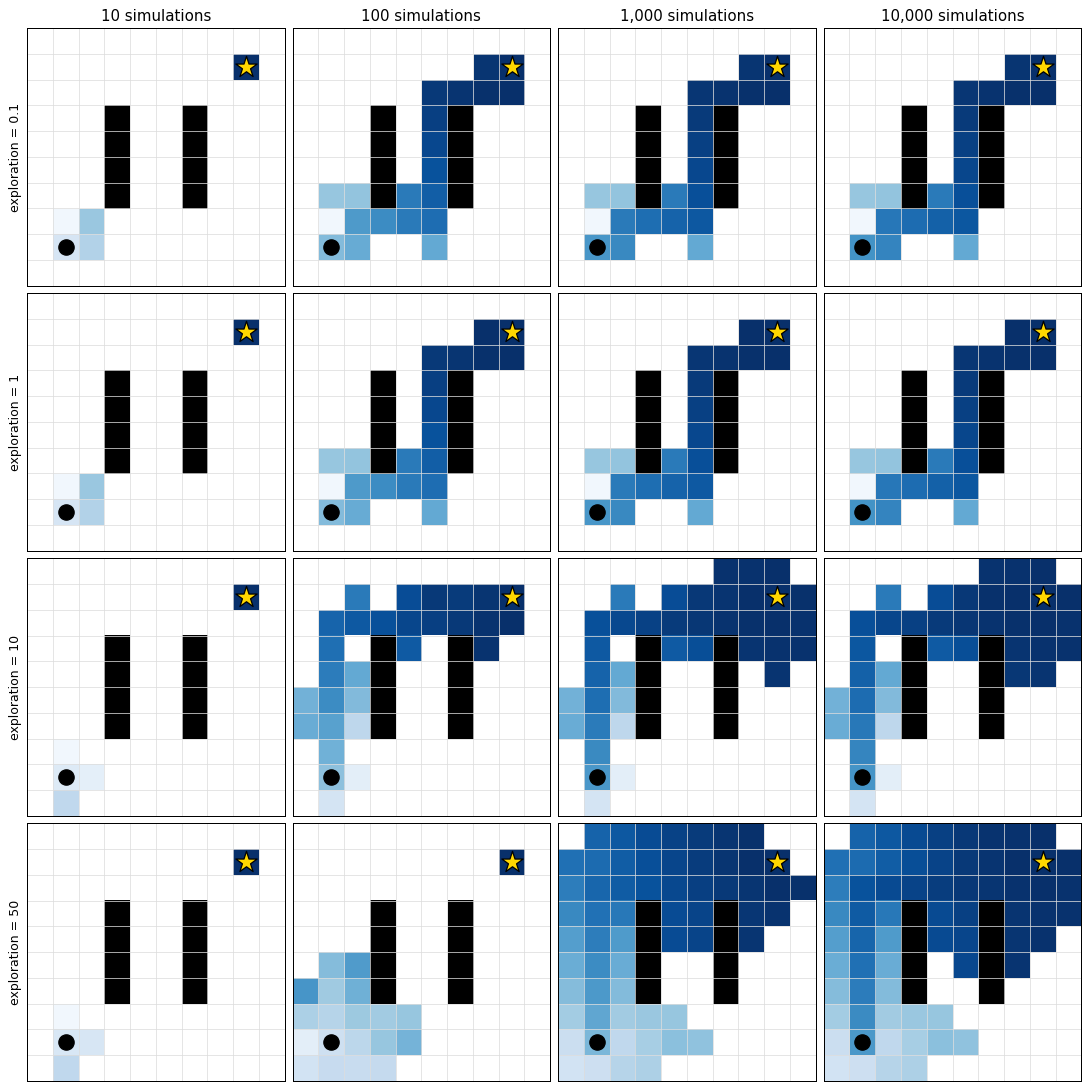

In [9]:
simulation_counts = [10, 100, 1000, 10000]
exploration_coefficients = [0.1, 1.0, 10.0, 50.0]
comparisons = {}

for exploration in exploration_coefficients:
    for num_sim in simulation_counts:
        world = GridWorld(num_sim=num_sim, exploration=exploration)
        outcome = world.search(key, start, goal)
        comparisons[exploration, num_sim] = spatial_action_values(outcome.tree, world)

minimum = min(np.nanmin(values) for values, _ in comparisons.values())
comparison_scale = Normalize(vmin=minimum, vmax=0)

fig, axes = comparison_axes()

for row, exploration in enumerate(exploration_coefficients):
    for column, num_sim in enumerate(simulation_counts):
        values, _ = comparisons[exploration, num_sim]
        draw_state_values(axes[row, column], search, state_values(values), comparison_scale, start)

plt.show()

In [10]:
current_state = start
path = [np.asarray(start)]
planning_frames = []
max_steps = 30

for step in range(max_steps + 1):
    outcome = search.search(jax.random.fold_in(key, step), current_state, goal)
    frame_q, frame_visits = spatial_action_values(outcome.tree, search)
    planning_frames.append((current_state, frame_q, frame_visits, np.asarray(path)))
    if bool(search.terminal(current_state, goal)) or step == max_steps:
        break
    action = outcome.actions[jnp.argmax(outcome.action_visits)]
    current_state = search.transition(current_state, action)
    path.append(np.asarray(current_state))

step_labels = [f"Step {i}" for i in range(len(planning_frames))]
animate_search(search, planning_frames, step_labels, interval=600)